In [1]:
# importing libraries
import pandas as pd 
import numpy as np
import matplotlib
import sklearn
import csv
import missingno as msno

# DATA
data_path = r"C:\Users\user\OneDrive\Documents\Coding-frutiger\ml_portfolio\ai4i2020.csv"

# establish df - and encoding measure
df = pd.read_csv(data_path)

In [2]:
# Explore 
df.head()


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
# decsribe columns
print(df.describe())


               UDI  Air temperature [K]  Process temperature [K]  \
count  10000.00000         10000.000000             10000.000000   
mean    5000.50000           300.004930               310.005560   
std     2886.89568             2.000259                 1.483734   
min        1.00000           295.300000               305.700000   
25%     2500.75000           298.300000               308.800000   
50%     5000.50000           300.100000               310.100000   
75%     7500.25000           301.500000               311.100000   
max    10000.00000           304.500000               313.800000   

       Rotational speed [rpm]   Torque [Nm]  Tool wear [min]  Machine failure  \
count            10000.000000  10000.000000     10000.000000     10000.000000   
mean              1538.776100     39.986910       107.951000         0.033900   
std                179.284096      9.968934        63.654147         0.180981   
min               1168.000000      3.800000         0.000000   

In [4]:
# Target Columns Table: 
print('Total and Percentage')
print(df['Machine failure'].value_counts())
print("-"*30)

# percentage view
print(df['Machine failure'].value_counts(normalize=True).round(3) * 100)
print("="*30)

print(df['TWF'].value_counts()) # tool wear failure) 
print("-"*30)
print(df['TWF'].value_counts(normalize=True).round(3) * 100)
print("="*30)

print(df['HDF'].value_counts()) # heat dissapation failure 
print("-"*30)
print(df['HDF'].value_counts(normalize=True).round(3) * 100)
print("="*30)

print(df['PWF'].value_counts()) # Power failure 
print("-"*30)
print(df['PWF'].value_counts(normalize=True).round(3) * 100)
print("="*30)

print(df['OSF'].value_counts()) # overtrain failure
print("-"*30)
print(df['OSF'].value_counts(normalize=True).round(3) * 100)
print("="*30)

print(df['RNF'].value_counts()) # chanige of 0.1% chace to fail regardless of process parameters. 
print("-"*30)
print(df['RNF'].value_counts(normalize=True).round(3) * 100)
print("="*30)
'''
Note: If at least one of the above failure modes is true, 
the process fails and the 'machine failure' label is set to 1. 
It is therefore not transparent to the machine learning method, 
which of the failure modes has caused the process to fail.
'''

Total and Percentage
Machine failure
0    9661
1     339
Name: count, dtype: int64
------------------------------
Machine failure
0    96.6
1     3.4
Name: proportion, dtype: float64
TWF
0    9954
1      46
Name: count, dtype: int64
------------------------------
TWF
0    99.5
1     0.5
Name: proportion, dtype: float64
HDF
0    9885
1     115
Name: count, dtype: int64
------------------------------
HDF
0    98.8
1     1.2
Name: proportion, dtype: float64
PWF
0    9905
1      95
Name: count, dtype: int64
------------------------------
PWF
0    99.0
1     1.0
Name: proportion, dtype: float64
OSF
0    9902
1      98
Name: count, dtype: int64
------------------------------
OSF
0    99.0
1     1.0
Name: proportion, dtype: float64
RNF
0    9981
1      19
Name: count, dtype: int64
------------------------------
RNF
0    99.8
1     0.2
Name: proportion, dtype: float64


"\nNote: If at least one of the above failure modes is true, \nthe process fails and the 'machine failure' label is set to 1. \nIt is therefore not transparent to the machine learning method, \nwhich of the failure modes has caused the process to fail.\n"

In [5]:
# Step 2 import packages and split data

#load specific libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# select features and target
features = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]',
            'Torque [Nm]', 'Tool wear [min]']

X = df[features]
y = df['Machine failure']

# split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#scale 
scaler = StandardScaler() # scalar to standardize data
X_train = scaler.fit_transform(X_train) # learning standard deviation and the mean, fitting data accordingly
X_test = scaler.transform(X_test) # "how many sd from the mean am I" - applied sd + mean from training data.


In [6]:
# explore shape
X_train.shape

# 8000 rows and 5 features (80% of data)

(8000, 5)

In [7]:
# Trainig Model - Random Forest 

# laod library
from sklearn.ensemble import RandomForestClassifier

# generating the model, applying to training data
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# one tree will fit poorly, but 100 random trees will average out the noise - variance reduction.
# setting max_features to sqrt() forces diversity in tree construction.

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Accuracy: 0.983
F1 Score: 0.679
ROC AUC: 0.966

               precision    recall  f1-score   support

           0       0.99      1.00      0.99      1939
           1       0.80      0.59      0.68        61

    accuracy                           0.98      2000
   macro avg       0.89      0.79      0.84      2000
weighted avg       0.98      0.98      0.98      2000



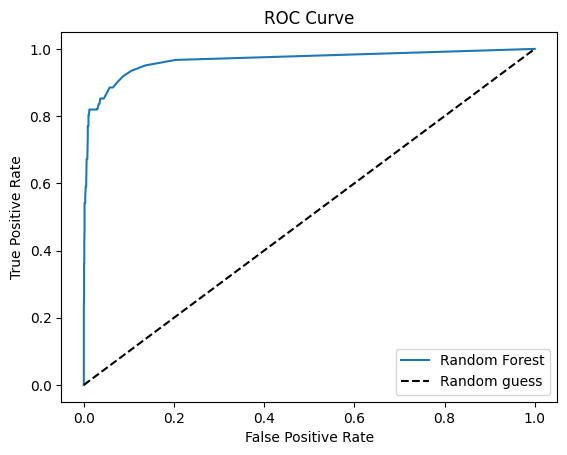

In [8]:
# import libraries
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, classification_report
import matplotlib.pyplot as plt

# Generate predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Metrics
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("F1 Score:", round(f1_score(y_test, y_pred), 3))
print("ROC AUC:", round(roc_auc_score(y_test, y_prob), 3))

# Full report
print("\n", classification_report(y_test, y_pred))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label='Random Forest')
plt.plot([0,1], [0,1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [ ]:
''' 
interpretation: 
F1-score = 0.54 i.e. mismatch in precision and recall.

model is reasonably good at confirming failures when it idenitifies them (high percision)

but still misses too many to be operationally reliable (low recall)

Solution: lower threshold to clearly identify higher degree of misses (false positives)
'''

25.009999999999998

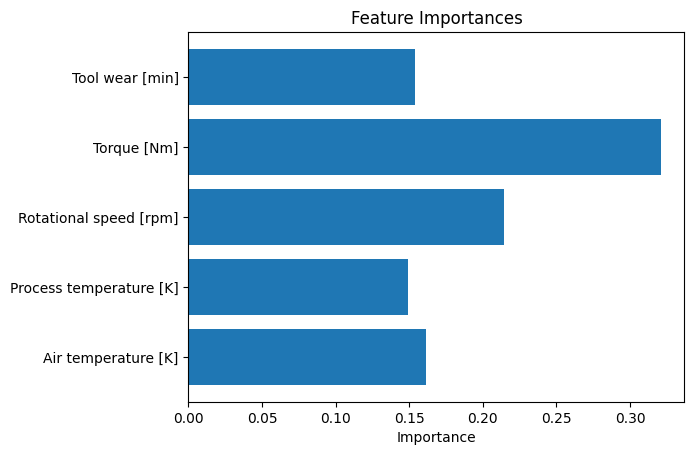

In [9]:
# Feature Importance:
importances = model.feature_importances_
feature_names = features

# graph
plt.barh(feature_names, importances)
plt.xlabel('Importance')
plt.title('Feature Importances')
plt.show()

# Interpretation: 
### What did we find:
Two scoring methods were used to forecast and categorize the potential machine failure given by the 5 relevant features of the dataset, namely Air temperature [K], Process temperature [K], Rotational speed [rpm], Torque [Nm] and Tool wear [min], over 10,000 data points from the AI4I 2020 Predictive Maintenance Dataset.

### What Each Metric Tells Us:
**Accuracy:** Accuracy shows the proportion of all correct predictions, both failure or non-failure, out of all predictions made. The simple percentage implicitly includes true positives, false positives, true negatives and false negatives — i.e. accuracy does not discern well between the types of predictions. It simply tells us the total number of predictions and how well these mapped onto the test set. This was reported back at 98.3%; however, this score is not reflective of the quality of the underlying predictions.

**ROC AUC:** Returned as 0.966, which tells us the model was able to rank random failures higher than non-failures 96.6% of the time.

**F1 Score:** The F1 score returned as 0.679. The F1 score is in reality a harmonic mean. The purpose of taking the harmonic mean is to aggressively punish lopsided models — i.e. to penalize extreme imbalances between precision and recall. Our precision and recall are approximately 0.21 percentage points apart. The harmonic mean is dominated by the smaller value, in this case recall.

**Precision**:  Our precision was 0.8. Meaning 80% of the failure predictions, specifically, were correct over all failure predictions made. Precision is our model's ability to accurately predict failures with respect to all failure predictions made — that is, predictions that were correct and predictions we called correct but were false.

**Recall:** In contrast, our recall was 0.59. Meaning 59% of the predictions made were correctly able to account for all true failures — i.e. true positives (predicted as failures and were) and false negatives (predicted as non-failures but weren't — actual failures).

Metric    | Value 
----------|----------
Accuracy  | 0.983
F1 Score  | 0.679
ROC AUC   | 0.966
Precision | 0.80
Recall    | 0.59

### Why were these numbers returned as strong?
Both our precision and recall are strong, which reflects the notion that neither is necessarily dominating the F1 score.

The model used n_estimators of 100 random trees and a subset of approximately 2 features to cast votes on each row/prediction. The quality of machine part readings are a strong predictor of machine health, which at least in part accounts for the high precision. The model was also fed a healthy number of rows to cast votes on — over large enough data, models tend toward higher performance.

High torque readings are the most predictive of failure. Feature importance reveals correlation and predictive signal, not causation. Torque might be a symptom of a deeper mechanical chain reaction. For example, torque stress may accelerate tool wear, which then drives failure.

### What would I tell Leadership?
A model with strong precision is good because we are actively identifying failures at a higher rate than we are making false positive predictions. Therefore, the model helps us attend to true machine failures often while minimizing the reporting of failures that did not actually occur. This saves the team from spending unnecessary time and resources on attending to issues that were never a problem — in other words, waste.

Further, our model boasts a recall of 59%, which means only 41% of the time the model is missing failures that actually occurred in our test set. 41% of the time, a prediction made as a non-machine failure could in fact be a failure. For regular maintenance this may not be an issue; however, in live theatre and operations this could mean loss of financial resources and life if that particular machine is skipped for maintenance.

The decision rests with leadership to determine whether the decision threshold (currently 0.5) should be lowered to sacrifice some precision for a better recall — i.e. how many more false flags this team would be willing to attend to in order to ensure that possible failures don't slip through the cracks. A lowering of the F1 score would be the result. The question is one of uncertainty tolerance, resource expenditure, and risk to operator life.

### Recommendation:
Continual use of the model is recommended. A confirmed balance, agreed upon by leadership in line with operational scope and objectives, is advised. For the foreseeable future, maintenance crews should pay close attention to high machine torque readings as the strongest predictor of machine failure.